In [1]:
# !pip install --upgrade scipy

In [2]:
import torch 
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable
from torch.utils.data import Dataset, DataLoader

import os, pathlib, glob, random
import numpy as np
import matplotlib.pyplot as plt 

from sklearn.metrics import confusion_matrix
import scipy
from scipy import io

In [3]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

cuda:0


In [4]:
batch_size = 64
output_nodes = 2
learning_rate = 0.003

In [5]:
train_data_path = r"/kaggle/input/dysarthricdataset/MFCC/MFCC/train"
test_data_path =r"/kaggle/input/dysarthricdataset/MFCC/MFCC/test"
validation_data_path= r"/kaggle/input/dysarthricdataset/MFCC/MFCC/val"

In [6]:
class PtDataset(Dataset):
    def __init__(self, directory):
        self.directory = directory
        self.classes = sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}
        self.files = []
        for c in self.classes:
            c_dir = os.path.join(directory, c)
            c_files = [(os.path.join(c_dir, f), self.class_to_idx[c]) for f in os.listdir(c_dir)]
            self.files.extend(c_files)
        random.shuffle(self.files)
        
    def __len__(self):
        return len(self.files)
    
    def __getitem__(self, idx):
        filepath, label = self.files[idx]
        try:
            mat_vals = scipy.io.loadmat(filepath)
            data = mat_vals['final']
            data = data.T
            max_len=600
            if (max_len > data.shape[0]):
                pad_width = max_len - data.shape[0]
                data = np.pad(data, pad_width=((0, pad_width),(0,0)), mode='constant')
            else:
                data = data[:max_len, :]
        except Exception as e:
            print(f"Error loading file {filepath}: {str(e)}")
            return None
        return data, label

In [7]:
train_dataset = PtDataset(train_data_path)
test_dataset = PtDataset(test_data_path)
val_dataset = PtDataset(validation_data_path)

In [8]:
class PtDataLoader(DataLoader):
    def __init__(self, directory, batch_size, shuffle=True):
        dataset = PtDataset(directory)
        super().__init__(dataset, batch_size=batch_size, shuffle=shuffle)

In [9]:
train_dataloader = PtDataLoader(directory=train_data_path, batch_size=batch_size)
test_dataloader = PtDataLoader(directory=test_data_path, batch_size=batch_size)
val_dataloader = PtDataLoader(directory=validation_data_path, batch_size=batch_size)

In [10]:
train_count = len(train_dataset) 
test_count = len(test_dataset)
val_count = len(val_dataset)

In [11]:
print(train_count)
print(test_count)
print(val_count)

199
43
65


In [12]:
import torch
from torch import nn
from torch.nn import Parameter
import torch.nn.functional as F

In [13]:
# Define the parameters
input_size = 20
hidden_size = 256
num_layers = 2
num_classes = 4
# drop_amount = 0.25  # You can choose an appropriate dropout rate

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim

In [15]:
import torch 
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable
from torch.utils.data import Dataset, DataLoader
import os, pathlib, glob, random
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.metrics import confusion_matrix
from transformers import WhisperProcessor, WhisperForConditionalGeneration
from datasets import load_dataset
from transformers.models.whisper.modeling_whisper import WhisperModel, WhisperEncoder
from transformers.models.whisper.configuration_whisper import WhisperConfig
from typing import Optional, Tuple, Union
import torch
import librosa 
import matplotlib.pyplot as plt
import numpy as np
import os, glob, pickle
import scipy.io as sio
from tqdm import tqdm
import multiprocessing as mp 
import torch.optim as optim

In [16]:
# BiLSTM

In [17]:
drop_amount = 0.255

class BiLSTMClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super(BiLSTMClassifier, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(p=drop_amount)
        self.fc = nn.Linear(hidden_size*2, num_classes)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers*2, x.size(0), self.hidden_size).to(device=x.device, dtype=torch.float64)
        c0 = torch.zeros(self.num_layers*2, x.size(0), self.hidden_size).to(device=x.device, dtype=torch.float64)
        out, _ = self.lstm(x, (h0, c0))
        out = self.dropout(out)
        # Extract the output of the last time step from both directions
        last_hidden_state = torch.cat((out[:, -1, :self.hidden_size], out[:, 0, self.hidden_size:]), dim=1)
        output = self.fc(last_hidden_state)
        return output

In [18]:
batch_size = 64
output_nodes = 4
learning_rate = 0.003

In [19]:
model = BiLSTMClassifier(input_size, hidden_size, num_layers, num_classes)
model.to(device, dtype=torch.float64)
loss_function = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
print(model)

BiLSTMClassifier(
  (lstm): LSTM(20, 256, num_layers=2, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.255, inplace=False)
  (fc): Linear(in_features=512, out_features=4, bias=True)
)


In [20]:
print(model)

BiLSTMClassifier(
  (lstm): LSTM(20, 256, num_layers=2, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.255, inplace=False)
  (fc): Linear(in_features=512, out_features=4, bias=True)
)


In [21]:
#Model training and testing 
n_total_steps = len(train_dataloader) # n_total_steps * batch size will give total number of training files (consider that last batch may not be fully filled)
train_accuracy_list = []
train_loss_list = []
val_accuracy_list = []
max_acc=0
num_epochs = 25
pred_labels =[]
act_labels = []

for epoch in range(num_epochs):
    
    #Evaluation and training on training dataset
    model.train()
    train_accuracy=0.0
    train_loss=0.0
    
    for batch_idx, (images,labels) in enumerate(train_dataloader):
        if torch.cuda.is_available():
            images=Variable(images.cuda())
            labels=Variable(labels.cuda())
        ##images = images.unsqueeze(1)
        optimizer.zero_grad()
        outputs=model(images)
        loss=loss_function(outputs,labels)
        loss.backward()
        optimizer.step()
        
        
        train_loss+= loss.cpu().data*images.size(0)
        _,prediction=torch.max(outputs.data,1)
        
        train_accuracy+=int(torch.sum(prediction==labels.data))
        
    train_accuracy=train_accuracy/train_count
    train_loss=train_loss/train_count
    
    train_accuracy_list.append(train_accuracy)
    train_loss_list.append(train_loss)

    
    # Validation on Validation dataset
    model.eval()
    val_accuracy=0.0
    pred = []
    lab = []
    
    for i, (images,labels) in enumerate(val_dataloader):
        if torch.cuda.is_available():
            images=Variable(images.cuda())
            labels=Variable(labels.cuda())
        ##images = images.unsqueeze(1) 
#         print(i,images.shape)
        outputs=model(images)
        _,prediction=torch.max(outputs.data,1)
        val_accuracy+=int(torch.sum(prediction==labels.data))
        
        pred.extend(prediction.tolist())
        lab.extend(labels.tolist())
    
    val_accuracy=val_accuracy/val_count
    val_accuracy_list.append(val_accuracy)
    if max_acc < val_accuracy:
        max_acc = val_accuracy
        pred_labels = pred
        actual_labels = lab
        max_acc = val_accuracy
        torch.save(model,"best_accuracy_model_BiLSTM.pth")
    print('Epoch : '+str(epoch+1)+'/'+str(num_epochs)+'   Train Loss : '+str(train_loss)+'   Train Accuracy : '+str(train_accuracy)+'   Vlidation Accuracy : '+str(val_accuracy))
print(max_acc)   
print('Finished Training and Validation')

Epoch : 1/25   Train Loss : tensor(1.2062, dtype=torch.float64)   Train Accuracy : 0.46733668341708545   Vlidation Accuracy : 0.5846153846153846
Epoch : 2/25   Train Loss : tensor(0.7743, dtype=torch.float64)   Train Accuracy : 0.628140703517588   Vlidation Accuracy : 0.6
Epoch : 3/25   Train Loss : tensor(0.6434, dtype=torch.float64)   Train Accuracy : 0.6683417085427136   Vlidation Accuracy : 0.5846153846153846
Epoch : 4/25   Train Loss : tensor(0.6330, dtype=torch.float64)   Train Accuracy : 0.6633165829145728   Vlidation Accuracy : 0.5846153846153846
Epoch : 5/25   Train Loss : tensor(0.6356, dtype=torch.float64)   Train Accuracy : 0.6733668341708543   Vlidation Accuracy : 0.6
Epoch : 6/25   Train Loss : tensor(0.6140, dtype=torch.float64)   Train Accuracy : 0.6683417085427136   Vlidation Accuracy : 0.5846153846153846
Epoch : 7/25   Train Loss : tensor(0.6444, dtype=torch.float64)   Train Accuracy : 0.6633165829145728   Vlidation Accuracy : 0.5846153846153846
Epoch : 8/25   Train L

In [22]:
# Load the best model
best_model = torch.load("best_accuracy_model_BiLSTM.pth")

# Put the best_model in evaluation mode
best_model.eval()

# Initialize variables to store results
testing_accuracy = 0.0
pred_labels = []
act_labels = []

# Pass validation data through the best model
for i, (images, labels) in enumerate(test_dataloader):
    if torch.cuda.is_available():
        images = Variable(images.cuda())
        labels = Variable(labels.cuda())
    
    outputs = best_model(images)
    _, prediction = torch.max(outputs.data, 1)
    
    testing_accuracy += int(torch.sum(prediction == labels.data))
    
    pred_labels.extend(prediction.tolist())
    act_labels.extend(labels.tolist())

# Calculate validation accuracy
testing_accuracy = testing_accuracy / len(test_dataloader.dataset)

# Print the validation accuracy
print("testing Accuracy:", testing_accuracy)

<ipython-input-22-740959cce2fe>:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_model = torch.load("best_accuracy_model_BiLSTM.pth")


testing Accuracy: 0.5348837209302325


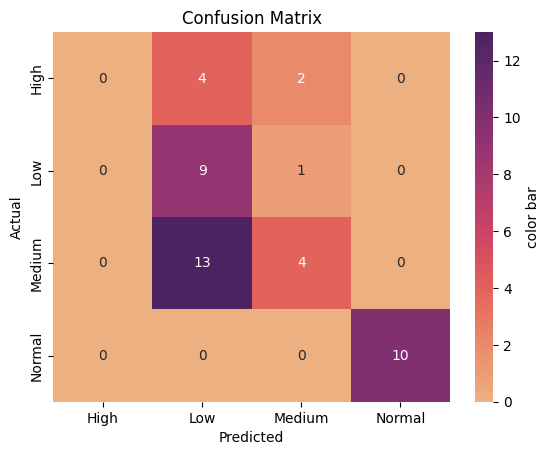

F1 Score :  0.4583333333333333


In [23]:
# Calculate the confusion matrix
import seaborn as sns
conf_mat = confusion_matrix(act_labels, pred_labels)
# Plot confusion matrix heat map
sns.heatmap(conf_mat, cmap="flare",annot=True, fmt = "g", 
            cbar_kws={"label":"color bar"},
            xticklabels=train_dataset.classes,
            yticklabels=train_dataset.classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.savefig("ConfusionMatrix_BiLSTM.png")
plt.show()
from sklearn.metrics import f1_score
f1_score = f1_score(pred_labels, act_labels, average='macro')
print('F1 Score : ', f1_score)
